# Tutorial 210: Conditional Flow Matching — PBMC with ESM2 Cytokine Conditions

Tutorial 200 showed conditional FM on synthetic two-moons data with a simple one-hot condition.
Here we scale up to real PBMC data and replace the one-hot with a **2560-dimensional ESM2
protein language model embedding** of the cytokine name.

* **Source**: PBS-treated cells (563 cells)
* **Target**: Cytokine-treated cells (90 usable cytokines)

In [1]:
%load_ext autoreload
%autoreload 2

## Contents

1. **Section 1**: Inline Components
2. **Section 2**: Load and Explore Data
3. **Section 3**: PCA Preprocessing
4. **Section 4**: DataManager Pipeline
5. **Section 5**: FTrainSampler
6. **Section 6**: Model Setup
7. **Section 7**: Training
8. **Section 8**: Inference for Selected Cytokines
9. **Section 9**: ODE Trajectories

In [2]:
import types
import numpy as np
import torch
import scanpy as sc
import matplotlib.pyplot as plt

from sc_flow.trainer._trainer import FlowTrainer
from sc_flow.backends.torch.nn import MLPUnconditionalVF
from sc_flow.backends.torch.coupling import independent_coupling
from sc_flow.backends.torch.probability_paths import LinearGaussianProbabilityPath
from sc_flow.backends.torch.solvers import ODESolver
from sc_flow import methods as basemethods
from sc_flow.data import DataManager, MatchedData
from sc_flow.data.samplers import FTrainSampler
from sc_flow.preprocessing import PCATransform

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## Section 1: Inline Components

`BaseMethod` is defined inline because branches not merged. THIS REMOVE LATER

In [3]:
class BaseMethod(basemethods.FlowMatching):
    """Minimal flow matching implementation used in this tutorial."""

    def __init__(self, vf, probability_path, time_sampler, solver, match_fn, opt=None, **kwargs):
        self.vf = vf
        self.probability_path = probability_path
        self.time_sampler = time_sampler
        self.match_fn = match_fn
        self.solver = solver
        self.opt = opt(self.vf.parameters(), lr=5e-4)
        self._is_trained = False
        self.vf_step_fn = self._get_vf_step_fn()

    def _get_vf_step_fn(self):
        def vf_step_fn(time, source, target, conditions):
            def loss_fn(t, src, tgt, cond):
                x_t = self.probability_path.compute_xt(t, src, tgt)
                v_t = self.vf(t, x_t, cond, src)
                u_t = self.probability_path.compute_ut(t, x_t, src, tgt)
                return torch.mean((v_t - u_t) ** 2)

            self.opt.zero_grad()
            loss = loss_fn(time, source, target, conditions)
            loss.backward()
            self.opt.step()
            return loss

        return vf_step_fn

    def step_fn(self, batch):
        """Compute one training step and return the loss tensor."""
        condition = batch.get("condition")
        source = batch["src_cell_data"]
        target = batch["tgt_cell_data"]
        time = self.time_sampler(source.shape[0])
        src_ixs, tgt_ixs = self.match_fn(source, target)
        source, target = source[src_ixs], target[tgt_ixs]
        # Reindex condition rows to stay aligned with target after coupling
        if condition is not None:
            condition = {k: v[tgt_ixs] for k, v in condition.items()}
        return self.vf_step_fn(time, source, target, condition)

    def train_step(self, batch, prng_key=None):
        """Run one gradient step and return the scalar loss."""
        return float(self.step_fn(batch).cpu())

    def predict(self, x, condition=None, **kwargs):
        """Push source cells to predicted target under the given cytokine condition."""
        time = torch.linspace(0.0, 1.0, 101)
        solver = ODESolver(dynamics=self.vf, method="euler", vf_kwargs={"condition_dict": condition})
        return solver.solve(x, time, rtol=1e-6, atol=1e-7)

    def predict_trajectory(self, x, condition=None, n_steps: int = 20):
        """Return the full ODE trajectory under the given condition.

        Shape: (n_steps, n_cells, n_dims). Used to visualise how cells move
        from PBS state (t=0) to predicted cytokine state (t=1) in PCA space.
        """
        time = torch.linspace(0.0, 1.0, n_steps)
        solver = ODESolver(dynamics=self.vf, method="euler", vf_kwargs={"condition_dict": condition})
        return solver.solve(x, time, rtol=1e-5, atol=1e-6, return_trajectory=True)


def uniform_time_sampler(n: int) -> torch.Tensor:
    """Sample n uniform random times in [0, 1]."""
    return torch.rand(size=(n,))

## Section 2: Load and Explore Data

The dataset contains 10,000 PBMC cells profiled across 2,000 highly variable genes.
- `obs['treatment']`: `'PBS'` (source, 563 cells) or `'cytokine'` (9437 cells)
- `obs['cytokine']`: one of 91 unique values including `'PBS'`
- `uns['esm2_embeddings']`: dict mapping cytokine name → 2560-dim ESM2 vector

In [4]:
DATA_PATH = r"C:\Users\HP\Documents\munich_work\CellFlow\pbmc_small.h5ad"
adata = sc.read_h5ad(DATA_PATH)
print(adata)

# Identify usable cytokines: must have both cell data AND ESM2 embeddings
cytokines_with_cells = set(adata.obs["cytokine"].unique()) - {"PBS"}
cytokines_with_esm2 = set(adata.uns["esm2_embeddings"].keys())
usable_cytokines = sorted(cytokines_with_cells & cytokines_with_esm2)
print(f"\nUsable cytokines: {len(usable_cytokines)}")
print(f"PBS source cells: {(adata.obs['treatment'] == 'PBS').sum()}")

AnnData object with n_obs × n_vars = 10000 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'cytokine_family'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_embeddings', 'esm2_embeddings', 'hvg', 'log1p'

Usable cytokines: 90
PBS source cells: 563


## Section 3: PCA Preprocessing

We reduce from 2,000 genes to 50 principal components using `PCATransform` and stored in `adata.obsm['X_pca']`.

PCA done. Shape: (10000, 50)


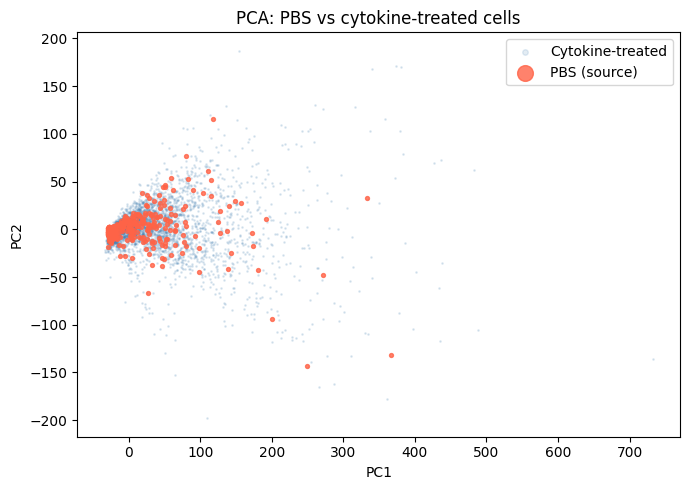

In [5]:
N_COMPONENTS = 50

# adata.X is a sparse matrix — convert to dense before fitting
X_dense = np.array(adata.X.todense()) if hasattr(adata.X, "todense") else np.array(adata.X)

pca = PCATransform(n_components=N_COMPONENTS)
adata.obsm["X_pca"] = pca.fit_transform(X_dense).astype(np.float32)
print(f"PCA done. Shape: {adata.obsm['X_pca'].shape}")

pbs_mask = adata.obs["treatment"].values == "PBS"
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    adata.obsm["X_pca"][~pbs_mask, 0],
    adata.obsm["X_pca"][~pbs_mask, 1],
    s=1,
    alpha=0.15,
    color="steelblue",
    label="Cytokine-treated",
)
ax.scatter(
    adata.obsm["X_pca"][pbs_mask, 0],
    adata.obsm["X_pca"][pbs_mask, 1],
    s=8,
    alpha=0.8,
    color="tomato",
    label="PBS (source)",
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA: PBS vs cytokine-treated cells")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

## Section 4: DataManager Pipeline

The `DataManager` compiles the AnnData into a `NestedData` tree where each leaf is a
`MatchedData` pairing PBS source cells with one cytokine's target cells.

- `sample_rep='X_pca'` — use 50-dim PCA coords as the state representation
- `conditions_reps={'cytokine_level': 'esm2_embeddings'}` — use ESM2 vectors as the condition
- `control_values_dict={'cytokine_level': 'PBS'}` — PBS cells are the source

In [6]:
manager = DataManager(
    sample_rep="X_pca",
    conditions={"cytokine_level": ["cytokine"]},
    conditions_reps={"cytokine_level": "esm2_embeddings"},
    control_values_dict={"cytokine_level": "PBS"},
)
nested_data = manager.compile_adata(adata)

inner = nested_data[()]
print(f"Total cytokine conditions: {len(inner.mapping)}")

first_key = list(inner.mapping.keys())[0]
ex = inner[first_key]
print(f"Example cytokine: {first_key[0]}")
print(f"  source cells: {ex.n_src_obs}  target cells: {ex.n_tgt_obs}")
print(f"  ESM2 dim: {list(adata.uns['esm2_embeddings'].values())[0].shape}")

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 90/90 [00:00<00:00, 643.35it/s]

Total cytokine conditions: 90
Example cytokine: 4-1BBL
  source cells: 563  target cells: 163
  ESM2 dim: (2560,)


## Section 5: FTrainSampler

In [7]:
def dispatch_fn(matched: MatchedData) -> dict:
    """Convert a sampled MatchedData into the training dict."""
    src = matched.source_distribution.state_data.X.astype(np.float32)
    tgt = matched.target_distribution.state_data.X.astype(np.float32)
    cyt_name = matched.target_distribution.condition_data.categorical_covariates.ann_df["cytokine"].iloc[0]
    repr_dict = matched.target_distribution.condition_data.categorical_covariates.repr_dict
    esm2_vec = torch.tensor(repr_dict["cytokine_level"][cyt_name], dtype=torch.float32)
    # Broadcast ESM2 vector to all cells in the batch: (batch, 2560)
    condition_tensor = esm2_vec.unsqueeze(0).expand(src.shape[0], -1)
    return {
        "src_cell_data": torch.tensor(src, dtype=torch.float32),
        "tgt_cell_data": torch.tensor(tgt, dtype=torch.float32),
        "condition": {"cytokine": condition_tensor},
    }


BATCH_SIZE = 256
_inner_sampler = FTrainSampler(
    nested_data,
    dispatch_fn,
    batch_size=BATCH_SIZE,
    n_nodes=1,
    replace_samples=True,
)
# FTrainSampler.sample() returns tuple[dict]; FlowTrainer expects plain dict
train_loader = types.SimpleNamespace(sample=lambda _=None: _inner_sampler.sample()[0])

batch = train_loader.sample()
print("src_cell_data:      ", batch["src_cell_data"].shape)
print("tgt_cell_data:      ", batch["tgt_cell_data"].shape)
print("condition[cytokine]:", batch["condition"]["cytokine"].shape)

src_cell_data:       torch.Size([256, 50])
tgt_cell_data:       torch.Size([256, 50])
condition[cytokine]: torch.Size([256, 2560])


## Section 6: Model Setup

The only change from Tutorial 110 (unconditional PBMC) is `condition_encoder_input_layers`.
This tells the velocity field to expect a tensor keyed `'cytokine'` with 2560-dim input
and encode it to a 64-dim representation before combining with the state and time encodings.

In [8]:
ESM2_DIM = 2560
STATE_DIM = N_COMPONENTS  # 50

vf = MLPUnconditionalVF(
    state_dim=STATE_DIM,
    encode_state=True,
    encode_time=True,
    time_features_id="torch-cfm",
    state_encoder_mlp_kwargs={"hidden_dims": (64,)},
    time_encoder_mlp_kwargs={"hidden_dims": (32,)},
    condition_encoder_output_layers_kwargs={"hidden_dims": (64,)},
    vf_decoder_mlp_kwargs={"hidden_dims": (128, 128)},
    condition_encoder_input_layers={"cytokine": {"input_dim": ESM2_DIM, "output_dim": 64}},
)

# solver used as default during training — predict() creates fresh solvers with conditions
solver = ODESolver(dynamics=vf, method="euler", vf_kwargs={"condition_dict": None})

model = BaseMethod(
    vf=vf,
    probability_path=LinearGaussianProbabilityPath(sigma=0.01),
    time_sampler=uniform_time_sampler,
    solver=solver,
    match_fn=independent_coupling,
    opt=torch.optim.AdamW,
)
trainer = FlowTrainer(method=model, require_prng=False)
print("Model ready.")
print(vf)

The probability path  LinearGaussianProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.


Model ready.
MLPUnconditionalVF(
  (_vf): ModuleDict(
    (time_features): FunctionalModule(
      (_identity): Identity()
    )
    (time_encoder): MLP(
      (_mlp): Sequential(
        (layer_0): Sequential(
          (linear): Linear(in_features=256, out_features=32, bias=True)
          (activation): ReLU()
        )
        (layer_1): Sequential(
          (linear): Linear(in_features=32, out_features=16, bias=True)
          (activation): Identity()
        )
      )
    )
    (state_encoder): MLP(
      (_mlp): Sequential(
        (layer_0): Sequential(
          (linear): Linear(in_features=50, out_features=64, bias=True)
          (activation): ReLU()
        )
        (layer_1): Sequential(
          (linear): Linear(in_features=64, out_features=32, bias=True)
          (activation): Identity()
        )
      )
    )
    (conditioning_layer): ConcatConditioning(
      (_identity): Identity()
    )
    (condition_encoder): SetEncoder(
      (_condition_encoder): ModuleDict(


## Section 7: Training

In [9]:
trainer.fit(train_dataloader=train_loader, num_iterations=10_000, valid_freq=10_001)

  0%|          | 0/10000 [00:00<?, ?it/s]Validation step requires validation data. Please prepare validation data with `model.prepare_validation_data()` method.
C:\Users\HP\AppData\Local\Temp\ipykernel_16088\10983684.py:40: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return float(self.step_fn(batch).cpu())
100%|██████████| 10000/10000 [02:25<00:00, 68.50it/s]


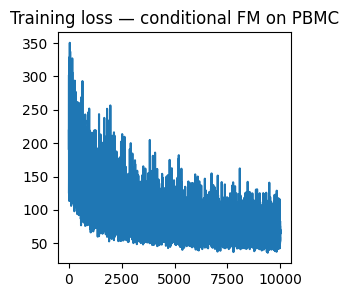

In [10]:
trainer.plot_training_logs()
plt.title("Training loss — conditional FM on PBMC")
plt.show()

## Section 8: Inference for Selected Cytokines

We pass the **same PBS source cells** through the model with different cytokine
conditions. Each condition should push the cells to a different region of PCA space.

In [11]:
CYTOKINES_TO_TEST = ["IFN-alpha2", "IL-2", "EGF", "CT-1"]
CYTOKINES_TO_TEST = [c for c in CYTOKINES_TO_TEST if c in usable_cytokines]
print("Testing:", CYTOKINES_TO_TEST)

N_INFERENCE = 200
pbs_pca = adata.obsm["X_pca"][pbs_mask].astype(np.float32)
src_idx = np.random.choice(pbs_pca.shape[0], size=N_INFERENCE, replace=False)
source_cells = torch.tensor(pbs_pca[src_idx], dtype=torch.float32)

Testing: ['IL-2', 'EGF', 'CT-1']


In [12]:
predictions = {}
model.vf.eval()
with torch.no_grad():
    for cyt in CYTOKINES_TO_TEST:
        matched = nested_data[()][(cyt,)]
        repr_dict = matched.target_distribution.condition_data.categorical_covariates.repr_dict
        esm2_vec = torch.tensor(repr_dict["cytokine_level"][cyt], dtype=torch.float32)
        condition = {"cytokine": esm2_vec.unsqueeze(0).expand(N_INFERENCE, -1)}
        pred = model.predict(source_cells, condition=condition)
        predictions[cyt] = pred.detach().numpy()
        print(f"  {cyt}: predicted shape {predictions[cyt].shape}")

  IL-2: predicted shape (200, 50)
  EGF: predicted shape (200, 50)
  CT-1: predicted shape (200, 50)


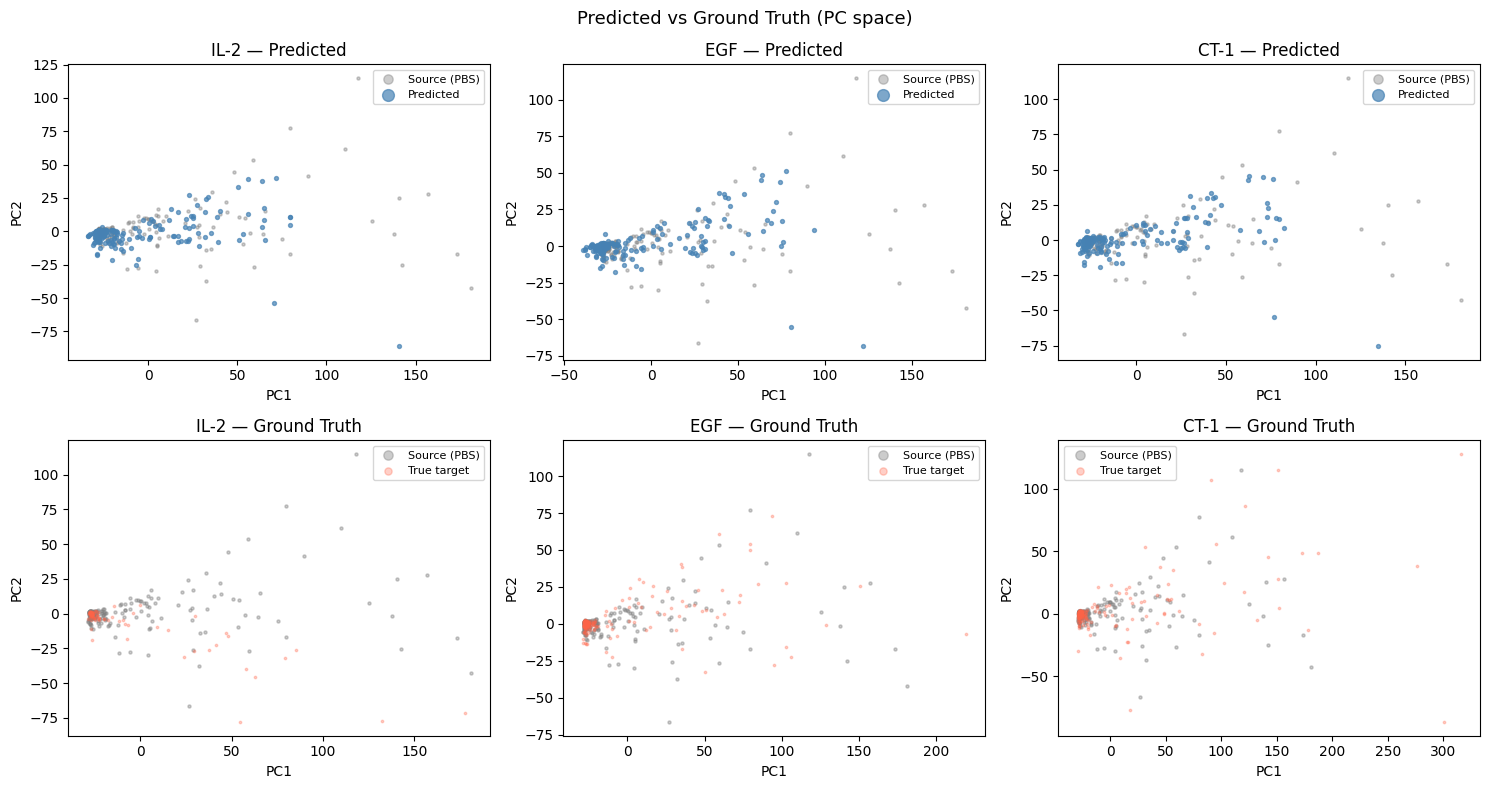

In [13]:
fig, axes = plt.subplots(2, len(CYTOKINES_TO_TEST), figsize=(5 * len(CYTOKINES_TO_TEST), 8))
if len(CYTOKINES_TO_TEST) == 1:
    axes = axes.reshape(2, 1)

for col, cyt in enumerate(CYTOKINES_TO_TEST):
    tgt_pca = nested_data[()][(cyt,)].target_distribution.state_data.X
    pred = predictions[cyt]

    axes[0, col].scatter(source_cells[:, 0], source_cells[:, 1], s=5, alpha=0.4, color="gray", label="Source (PBS)")
    axes[0, col].scatter(pred[:, 0], pred[:, 1], s=8, alpha=0.7, color="steelblue", label="Predicted")
    axes[0, col].set_title(f"{cyt} — Predicted")

    axes[1, col].scatter(source_cells[:, 0], source_cells[:, 1], s=5, alpha=0.4, color="gray", label="Source (PBS)")
    axes[1, col].scatter(tgt_pca[:, 0], tgt_pca[:, 1], s=3, alpha=0.3, color="tomato", label="True target")
    axes[1, col].set_title(f"{cyt} — Ground Truth")

    for row in range(2):
        axes[row, col].set_xlabel("PC1")
        axes[row, col].set_ylabel("PC2")
        axes[row, col].legend(markerscale=3, fontsize=8)

plt.suptitle("Predicted vs Ground Truth (PC space)", fontsize=13)
plt.tight_layout()
plt.show()

## Section 9: ODE Trajectories

Here we visualise how a small set of PBS source cells travel through PCA space as the
ODE integrates from t=0 to t=1 under two different cytokine conditions.

Under different conditions the **same PBS starting cells** follow **different paths**,
arriving at different regions of PCA space — that is what the condition encoder has learned.

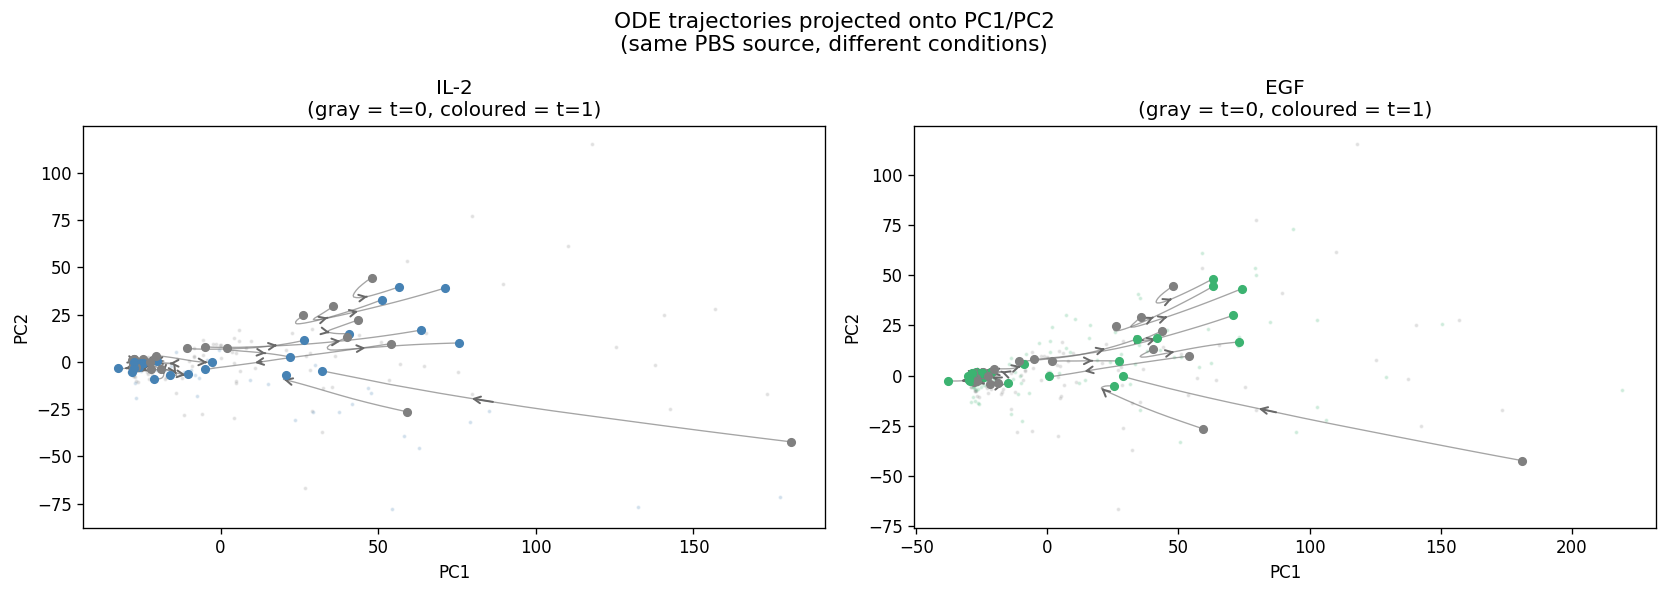

In [14]:
# Pick two cytokines to compare side by side
CYT_A, CYT_B = CYTOKINES_TO_TEST[0], CYTOKINES_TO_TEST[1]

N_TRAJ = 30
src_small = source_cells[:N_TRAJ]  # same cells for both conditions


def get_condition(cyt, n_cells):
    """Build the condition dict for ``cyt`` with ``n_cells`` rows."""
    repr_dict = nested_data[()][(cyt,)].target_distribution.condition_data.categorical_covariates.repr_dict
    esm2_vec = torch.tensor(repr_dict["cytokine_level"][cyt], dtype=torch.float32)
    return {"cytokine": esm2_vec.unsqueeze(0).expand(n_cells, -1)}


model.vf.eval()
with torch.no_grad():
    traj_a = model.predict_trajectory(src_small, condition=get_condition(CYT_A, N_TRAJ), n_steps=20)
    traj_b = model.predict_trajectory(src_small, condition=get_condition(CYT_B, N_TRAJ), n_steps=20)

traj_a_np = traj_a.numpy()  # (n_steps, N_TRAJ, 50)
traj_b_np = traj_b.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

for ax, traj_np, cyt, tgt_color in [
    (axes[0], traj_a_np, CYT_A, "steelblue"),
    (axes[1], traj_b_np, CYT_B, "mediumseagreen"),
]:
    tgt_pca = nested_data[()][(cyt,)].target_distribution.state_data.X

    # Background populations
    ax.scatter(source_cells[:, 0], source_cells[:, 1], s=2, alpha=0.15, color="gray")
    ax.scatter(tgt_pca[:, 0], tgt_pca[:, 1], s=2, alpha=0.15, color=tgt_color)

    mid = traj_np.shape[0] // 2
    for i in range(N_TRAJ):
        ax.plot(traj_np[:, i, 0], traj_np[:, i, 1], lw=0.8, alpha=0.6, color="dimgray")
        ax.annotate(
            "",
            xy=(traj_np[mid + 1, i, 0], traj_np[mid + 1, i, 1]),
            xytext=(traj_np[mid, i, 0], traj_np[mid, i, 1]),
            arrowprops={"arrowstyle": "->", "color": "dimgray", "lw": 1.2},
        )
        ax.scatter(traj_np[0, i, 0], traj_np[0, i, 1], s=20, color="gray", zorder=5)
        ax.scatter(traj_np[-1, i, 0], traj_np[-1, i, 1], s=20, color=tgt_color, zorder=5)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(f"{cyt}\n(gray = t=0, coloured = t=1)")

plt.suptitle("ODE trajectories projected onto PC1/PC2\n(same PBS source, different conditions)", fontsize=13)
plt.tight_layout()
plt.show()

### What's next?

| Tutorial | What it introduces |
|---|---|
| [`300_genot_pancreas.ipynb`](300_genot_pancreas.ipynb) | GENOT: unbalanced optimal transport for single-cell data |